# Data Procesing And Data Mining


## Introducción al análisis de datos de *simulaciones hidrodinámicas* 

## Objetivos

- Comprender de manera general cómo se organizan las bases de datos en simulaciones hidrodinámicas.
- Aprender a acceder a los datos públicos de la colaboración IllustrisTNG. 


----------------

### Simulaciones IllustrisTNG 

Las simulaciones IllustrisTNG son el intento más ambicioso de correr con un mismo modelo de formación magneto-hidrodinámico de galaxias, el mayor número cajas cosmológicas de distinto tamaño 
y resolución de partícula/celdas. Son hoy en dia 20 simulaciones en total, en tres tamaños de caja cosmológica (50 , 100 y 300 Mpc de lado), para cada tamaño, 3 resoluciones diferentes (e.g., TNG100-1,TNG100-2,TNG100-3), aunque TNG50 tiene una resolución adicional, y todas están en versión Only Dark Matter e hidrodinámica. Todas sus datos son de dominio público.  El modelo físico utilizado se llama AREPO (Springel et al.2010), que desde el año 2019 tambien es público (https://arepo-code.org/). Es un modelo Euleriano. A diferencia de los modelos de Smooth Particle Hydrodynamics (SPH), que calcula la evolución dinámica de partículas, AREPO considera al espacio subdividido en celdas, que van cambiando su forma dependiendo de las necesidades de resolución.  Este tipo de modelos supone varias ventajas a la hora de modelar la hidrodinámica del gas, como un mejor comportamiento en zonas de shocks.  Además, es uno de los primeros que involucra el magetismo en las ecuaciones hidrodinámicas (Ver por ej, Pakmor 2016).  La mejor manera de conocer en detalle el proyecto es navegar por su página https://www.tng-project.org/, y leer los papers asociados https://www.tng-project.org/results/ . 


In [1]:
# importamos librerías necesarias, fundamentalmente el paquete illustris_python, que contiene los módulos necesarios para acceder a los datos. 

import illustris_python as il 
import matplotlib.pyplot as plt
import numpy as np

### ¿Cómo se guardan los datos en la simulación? ¿Como accedemos a ellos?  

#### paquete illustris_python 

**Snapshots**

Las simulaciones guardan información de diferentes maneras, a lo largo de sus *snapshots*. Los snapshots son los momentos en los cuales la información es almacenada.  La simulación corre con un tiempo de integración muy pequeño, pero las variables sólo se pueden escribir en un conjunto finito de "momentos", por cuestiones de espacio. Las simulaciones cosmológicas en general tienen del orden de ~100 snapshots. IllustrisTNG tiene 100, aunque sólo 20 de ellos son completos para las partículas, el resto sólo contiene algunos "campos". Los "campos" son las variables disponibles para las partículas(posiciones, magnitudes, etc), y se pueden consultar en las especificaciones de los datos, en la página: https://www.tng-project.org/data/docs/specifications/ Para dimensionar de lo que hablamos, sólo un *snapshot* de TNG50-1 (La realización de mayor resolución) pesa ~320 TB, aunque la mayor parte corresponde a las partículas.      

**Postprocesado , identificación de Halos y subestructuras, catálogos de grupos**

Otra característica importante de este tipo de simulaciones es su postprocesado de los datos.  Los datos fundamentales de las simulaciones son las posiciones, velocidades, masas y un número de variables más de las partículas. Sin embargo las bases de datos incluyen mucha más información que eso, procesada luego de corrida la simulación. Dos pasos fundamentales de organización de los datos son la identificación de Halos utilizando un algoritmo Friends of Friends (FoF) y la identificación de subestructuras físicas (los subhalos de materia oscura que rodean las galaxias, y las galaxias), con algoritmos específicos diseñados para eso (los más conocidos son Subfind o ROCKSTAR). Los subgrupos de IllustrisTNG son identificados usando el algoritmo *Subfind*.  De esta manera, además de las partículas, la base de datos contiene un catálogo de grupos. En este catálogo están contenidos tanto los "grupos" o halos FoF, y los subgrupos (galaxias).   
En este catálogo de grupos tenemos muchísima información postprocesada, desde masa total, masa de DM, masa estelar, de gas, radio a mitad de masa, etc. Siempre tener a mano la página de especificaciones de los datos : https://www.tng-project.org/data/docs/specifications/

Vale la aclaración de terminología de la colaboración: 

- "Group", "FoF Group", and "FoF Halo" all refer to halos.
- "Subgroup", "Subhalo", and "Subfind Group" all refer to subhalos.
- The first (most massive) subgroup of each halo is the "Primary Subgroup" or "Central Subgroup".
- All other following subgroups within the same halo are "Secondary Subgroups", or "Satellite Subgroups".

**Árboles de fusión , trees** 

Un tercer nivel de organización de los datos son los árboles de fusión (merger trees). Además de identificar los halos y las subestructuras en cada snapshot, luego hay que ver cómo estos halos y subestructuras se relacionan con las de snapshots anteriores. La separación entre snapshots en tiempo físico es del orden de 100-300 Myrs, dependiendo el redshift. En ese intervalo de tiempo los subhalos sufren cambios, y muchos se fusionan con el subhalo central. Hay algoritmos dedicados a hacer esta identificación uno a uno de los subhalos en difrentes snapshots, que construyen lo que se llama árboles de fusión o merger trees. De nuevo, hay que recurrir a la página para entender la nomenclatura y campos posibles una vez descargado el árbol de fusión de un dado subhalo.   https://www.tng-project.org/data/docs/specifications/ . 

Los datos de la simulación se acceden utilizando los módulos presentes en el paquete **illustris_python**. Se puede descargar desde la página también y ya está incluido en este servidor. 



### Funciones para el nivel de grupos (modulo groupcat):

Con este grupo de funciones podemos acceder al catálogo de Halos (FOF identificados con un algoritmo Friend of Friends) y subhalos (indentificados con subfind).

In [10]:
#illustris_python.groupcat.    *nosotros renombramos illustris_python como il.

def loadSubhalos(basePath, snapNum, fields=None):
    """ Load all subhalo information from the entire group catalog for one snapshot
       (optionally restrict to a subset given by fields). """
       
def loadHalos(basePath, snapNum, fields=None):
    """ Load all halo information from the entire group catalog for one snapshot
       (optionally restrict to a subset given by fields). """
       
def loadHeader(basePath, snapNum):
    """ Load the group catalog header. """
    
def load(basePath, snapNum):
    """ Load complete group catalog all at once. """
    
def loadSingle(basePath, snapNum, haloID=-1, subhaloID=-1):
    """ Return complete group catalog information for one halo or subhalo. """

### Nivel de partículas (modulo snapshot):

In [11]:
#illustris_python.snapshot.      *nosotros renombramos illustris_python como il --> por ejemplo:  il.snapshot.loadSubhalo(basePath, snapNum, id, fields=['SubhaloMass'])

def loadSubset(basePath, snapNum, partType, fields=None):
    """ Load a subset of fields for all particles/cells of a given partType. """
        
def loadSubhalo(basePath, snapNum, id, partType, fields=None):
    """ Load all particles/cells of one type for a specific subhalo
        (optionally restricted to a subset fields). """
        
def loadHalo(basePath, snapNum, id, partType, fields=None):
    """ Load all particles/cells of one type for a specific halo
        (optionally restricted to a subset fields). """

### Nivel de merger tree (modulo sublink): 

In [12]:
#illustris_python.sublink.    *nosotros renombramos illustris_python como il --> por ejemplo: il.sublink.loadTree()
    
def loadTree(basePath, snapNum, id, fields=None, onlyMPB=False):
    """ Load portion of Sublink tree, for a given subhalo, in its existing flat format.
        (optionally restricted to a subset fields). """

Todas las funciones tienen como argumento:

    basePath : Es el path a las simulaciones, en este servidor se encuentran en : basePath = '../sims.TNG/TNGa-b/output/', donde a puede ser 100 o 300 y b 1,2,3, correspondientes a las 3 resoluciones disponibles.
    
    snapNum:  Es el número de snapshot 
        
Algunas tienen como argumento el ID del halo o del subhalo.
Varias contienen el argumento *fields*, si no mencionamos ningún nombre de campo, carga todos los posibles. Las listas de campos están en:  https://www.tng-project.org/data/docs/specifications/
            

## PARTICULAS

In [3]:
h = 0.6774

idHalo = 6
partType = '4'   # puede ser el string 'gas', dm', 'stars', o bien un número (0,1,4 en este caso).  En la página de descripción de los datos 

fieldspart = ['Coordinates', 'Velocities','Masses']
basePath = '../sims.TNG/TNG100-1/output/'
snapNum = 99

#CONSEGUIMOS LAS PARTÍCULAS DEL HALO con id = idHalo (Pedimos sus coordenadas y velocidades sólamente)

Halo = il.snapshot.loadHalo(basePath, snapNum, idHalo, 'dm', fields=fieldspart)

#AHORA TENEMOS QUE ENCONTRAR CUAL ES EL ID DEL SUBHALO CENTRAL DE ESTE HALO FoF. 

#Recurrimos a las funciones del modulo groupcat, para acceder al catálogo de grupos. 
#Una de las variables almacenadas para cada Halo FoF, es el ID de subhalo de su subestructura central. Guardamos esa información de todos los halos 

GroupFirstSub = il.groupcat.loadHalos(basePath,snapNum,fields=['GroupFirstSub'])


print('Cuantos halos FoF tiene la simulación? Respuesta:', len(GroupFirstSub))
print('el ID de subhalo del subhalo central de el Halo ', idHalo,' es', GroupFirstSub[idHalo])
subcenhid = GroupFirstSub[idHalo]


SubHaloDM = il.snapshot.loadSubhalo(basePath, snapNum, subcenhid, 'dm', fields=fieldspart)
SubHaloGal = il.snapshot.loadSubhalo(basePath, snapNum, subcenhid, 'stars', fields=fieldspart)

coordH = Halo['Coordinates'] / h    #Unidades de kpc comóviles, referenciado en la caja cosmológica, de tamaño 75000 kpc/ h , con centro en uno de los vértices 
coordSubH = SubHaloDM['Coordinates']  / h
coordGal = SubHaloGal['Coordinates']  / h

# LAS COORDENADAS ESTÁN EXPRESADAS EN KPC COMÓVILES EN EL SISTEMA DE REFERENCIA DE LA CAJA (CUYO 0 ES UNA DE LAS ESQUINAS)
# LE RESTAMOS A CADA PARTICULA LA POSICIÓN DEL SUBHALO PARA QUE QUEDE TODO REFERIDO AL SUBHALO CENTRAL. PARA ACCEDER A ESTA POSICIÓN
# RECURRIMOS AL MODULO groupcat, del paquete illustris_python. Usamos la función loadSingle, porque sólo queremos la información de ese subhalo

shcat = il.groupcat.loadSingle(basePath, snapNum, subhaloID=subcenhid)
#Utilizar la variable shcat['SubhaloPos'] para hacer una traslación al sistema centrado en el subhalo


print('en base a qué ajustamos los límites?')
#utilizar la variable 'SubhaloVmaxRad' del catálogo de grupos, multiplicarlo por 10



Cuantos halos FoF tiene la simulación? Respuesta: 6291349
el ID de subhalo del subhalo central de el Halo  6  es 69507
en base a qué ajustamos los límites?


<img src="3panels-halos.png">

## TREES

Una de los usos del árbol de fusiones o merger tree, es acceder rápidamente a la evolución de alguna cantidad de un dado subhalo. De manera que sólo nos interesa la "rama principal" del árbol. Es decir, aquella que guarda información del halo en consideración hacia el pasado, y no nos interesa la información de los subhalos que alguna vez se fusionaron con este en el pasado.  

Aquí veremos cómo evoluciona la masa total de la subestructura central del halo del ejercicio 1. 

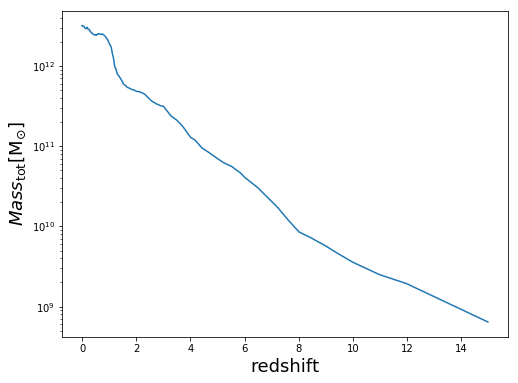

In [9]:

#Nota. En este ejemplo estamos graficando la masa total. En la práctica se pide graficar la masa estelar
    
fieldst = ['SubhaloMass','SubfindID','SnapNum']
snapNum = 99

    #Utilizamos la opción onlyMPB = True, porque sólo nos interesa 
tree = il.sublink.loadTree(basePath,snapNum,GroupFirstSub[idHalo],fields=fieldst,onlyMPB=True)     
    
redshifts = get_redshift_vec(tree['SnapNum'])  # HACER UNA FUNCION LLAMADA get_redshift, que utilizando como input un vector de números de snapshots, devuelva
                                               # un vector de redshifts . Hacer uso de la función loadHeader, del módulo groupcat, del paquete illustris_python. 
                                               # NO está incluida en este notebook. 
    
fig, ax = plt.subplots(1,1,figsize=(8,6))
    
ax.plot(redshifts,tree['SubhaloMass']*1e10/h,'-')
ax.set_yscale('log')
ax.set_xlabel('redshift', fontsize=18)
ax.set_ylabel(r'$Mass_{\rm tot} [{\rm M_{\odot}}]$',fontsize=18)

plt.show()

El segundo uso de los merger tress, un poco más complejo, consiste en seguir el arbol completo de fusión, con el objetivo, en general, de obtener información de las carcterísticas de las fusiones que experimentó un dado halo. Para esto, hay que hacer uso de los IDs del árbol de fusión. En los mergers trees, cada subhalo tiene un ID único que corresponde con su posición en el merger tree. En el caso de Illustris, este ID se llama 'SubhaloID'. El mismo subhalo en un snapshot subsiguiente, tendrá el número correlativo. Por ejemplo, el subhalo central del halo más masivo tiene SubhaloID = .....0 en el snapshot 0. Su principal progenitor (él mismo en el snapshot anterior), tendría SubhaloID = ....1. Veamoslo. 


In [4]:
fieldst2 = ['SubhaloID','FirstProgenitorID', 'NextProgenitorID']

tree2 = il.sublink.loadTree(basePath,snapNum,GroupFirstSub[0],fields=fieldst2, onlyMPB=False)  # En este caso queremos todo el árbol.   

print('tree2[SubhaloID]', tree2['SubhaloID'])
print('cuántos subhalos tiene el tree? Respuesta:', len(tree2['SubhaloID']))


tree2[SubhaloID] [10000000000000000 10000000000000001 10000000000000002 ...
 10000000001032530 10000000001032531 10000000001032532]
cuántos subhalos tiene el tree? Respuesta: 1032533


Los dos arrays mas importantes dentro del tree son los 'FirstProgenitorID' y los 'NextProgenitorID'. Esos arrays son los que nos van a permitir recorrer el árbol hacia "atrás", por su tronco, (FirstProgenitorID) y hacia el "costado" (NextProgenitorID), es decir, a lo largo de sus ramas. Apoyarse con el esquema de árbol que está en la descripción de los datos de la página de Illustris par entenderlo. 

In [5]:
print('tree2[FirstProgenitorID]',tree2['FirstProgenitorID'])
print('')
print('tree2[NextProgenitorID]',tree2['NextProgenitorID'])

tree2[FirstProgenitorID] [10000000000000001 10000000000000002 10000000000000003 ...
 10000000001032531 10000000001032532                -1]

tree2[NextProgenitorID] [               -1 10000000000962495 10000000000938192 ...
                -1                -1                -1]


Imaginemos que recorremos los dos vectores, llamando al First y Nextprogenitor que corresponda. Cuando el FirstProgenirID es -1, quiere decir que se identifica más ese subhalo hacia el pasado, es decir que todavía no se había formado. Cuando el NextProgenitorID es -1 , significa que en ese snapshot ya no hubo más fusiones con la rama principal. Veamoslo.

In [6]:
#ASI SE RECORRE EL MERGER TREE: 
#Definimos el ID original en el tree, del subhalo de interes. 

index=0   #index es simplemente un indice de inicialización, que definimos en 0, es decir corresponde al último snapshot
rootID = tree2['SubhaloID'][index]
fpID   = tree2['FirstProgenitorID'][index]   #iniciamos el first progenitor. Mientras sea distinto de -1, seguimos recorriendo para atrás del árbol. 

while fpID != -1:
    fpIndex = index + (fpID - rootID)  # Como los IDs son números grandes y raros, y nosotros necesitamos el índice en el array, hacemos esta cuenta. 

    # recorremos el árbol a lo ancho ahora
    npID = tree2['NextProgenitorID'][fpIndex]

    while npID != -1:
        npIndex = index + (npID - rootID)

        npID = tree2['NextProgenitorID'][npIndex]

    fpID = tree2['FirstProgenitorID'][fpIndex]

    
